In [1]:
import numpy as np 

In [2]:
class Linear_Regression():
    # initialting the parameters (learning_rate, no_of_itr)
    def __init__(self,learning_rate, no_of_itr):

        self.learning_rate = learning_rate
        self.no_of_itr = no_of_itr

    # X-> yr of experience , Y-> Salary
    def fit(self,X,Y):
        # no of training examples and no of features
        self.m, self.n = X.shape

        # initiating weight and bias
        self.w = np.zeros(self.n)
        self.b = 0
        self.X = X
        self.Y = Y

        # implementing gradient descent
        for i in range(self.no_of_itr):
            self.update_weight()

    def update_weight(self,):
        Y_prediction = self.predict(self.X)

        # calculate gradient
        dw = -(2 * (self.X.T).dot(self.Y - Y_prediction))/self.m

        db = -(2 * np.sum(self.Y - Y_prediction))/self.m

        # updating the vaues w & b 

        self.w = self.w - self.learning_rate*dw
        self.b = self.b - self.learning_rate*db


    def predict(self,X):    
        return X.dot(self.w) + self.b


## Using Linear Regression model for prediction

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Data Processing

In [9]:
df = pd.read_csv("salary_data.csv")

In [10]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [11]:
df.tail()

,YearsExperience,Salary
25,9.0,105582
26,9.5,116969
27,9.6,112635
28,10.3,122391
29,10.5,121872


In [12]:
df.shape

(30, 2)

In [15]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

### Splitting the features

In [17]:
x = df.iloc[:,:-1].values
y = df.iloc[:,1].values

### Sptting into training and test data

random_state value  controls how the data is randomly split

>>> Without random_state:

Run 1 → rows 1,4,7 go to test set
Run 2 → rows 2,5,9 go to test set

>>> With random_state=2:

Run 1 → rows 1,4,7 go to test set
Run 2 → rows 1,4,7 go to test set — always same

In [20]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.33,random_state=2)

## Training Linear Regression Model

In [54]:
model = Linear_Regression(learning_rate=0.02,no_of_itr=100)

In [55]:
model.fit(x_train,y_train)

## Building the Parameter(Weight & Bias)

In [56]:
print("Weight: ",model.w[0])
print("Bias: ",model.b)

Weight:  10941.258155090314
Bias:  13499.045037502532


In [57]:
prediction = model.predict(x_test)
print(prediction)

[ 27722.68063912  25534.4290081   62734.70673541  53981.70021134
  91181.97793864  79146.59396804 103217.36190924  46322.81950277
  35381.56134768  87899.60049212]


### Visualizing the predicted and actual values

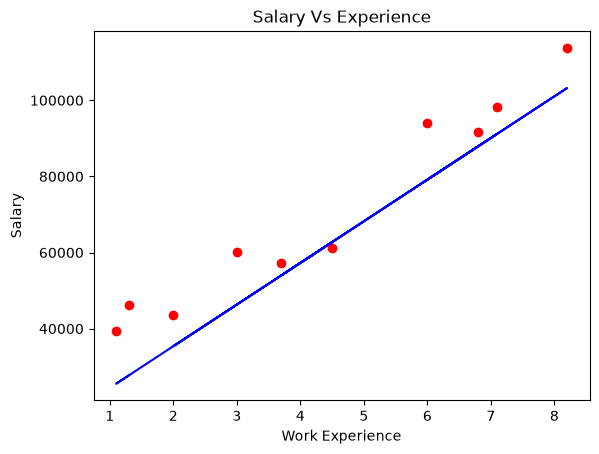

In [58]:
plt.scatter(x_test,y_test,color = 'red')
plt.plot(x_test,prediction,color = 'blue')
plt.xlabel("Work Experience")
plt.ylabel("Salary")
plt.title("Salary Vs Experience")
plt.show()